# 09D — Decentralised Solid Pod + Federated Learning (Clean, Runnable)

**Two separate ideas, kept separate so nothing overwrites anything:**

* **Physical Solid Pods (5)** — used for the *access-control security demonstration*
  (raw data lives in a pod; an agent can read only its own pod; the aggregator cannot
  read raw pod data). Variable: `POD_MAPPING`.
* **Federated clients (all eligible participants)** — logical clients for the
  *federated learning evaluation*, each building features locally and sending only
  weights. Variable: `FED_CLIENTS`.

**Run top to bottom. Edit only the two paths in Cell 1.**

Order: 1 config → 2 feature builder → 3 load data → 4 distribute to 5 pods →
5 define federated clients → 6 security model → 7 local train + export weights →
8 FedAvg global model → 9 evaluate federated vs centralised → 10 access-control
verification → 11 per-participant equivalence → 12 dissertation wording.


In [1]:
# ============================================================
# 1. CONFIG  ---  edit ONLY these two paths
# ============================================================
import os, json, warnings
from pathlib import Path
from collections import Counter
from datetime import datetime
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

PROJECT_PATH  = Path(r"C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation")
CSS_DATA_PATH = Path(r"C:\Users\Shabnam\SolidServer\data")

CLEAN_PATH = PROJECT_PATH / "01_cleaned_data"
OUTPUT_PATH   = PROJECT_PATH / "decentralised_solidpod_federated_workflow"
UPDATE_INBOX  = OUTPUT_PATH / "model_update_inbox"
GLOBAL_MODEL_PATH = OUTPUT_PATH / "global_model"
REPORT_PATH   = OUTPUT_PATH / "reports"
for p in [OUTPUT_PATH, UPDATE_INBOX, GLOBAL_MODEL_PATH, REPORT_PATH]:
    p.mkdir(parents=True, exist_ok=True)

# 5 PHYSICAL pods (security demo only) -- this is NEVER overwritten
POD_MAPPING = {
    "patient1": {"participant_id": "A4F_10021", "pod_folder_name": "patient1-1"},
    "patient2": {"participant_id": "A4F_10141", "pod_folder_name": "patient2"},
    "patient3": {"participant_id": "A4F_10355", "pod_folder_name": "patient3"},
    "patient4": {"participant_id": "A4F_10660", "pod_folder_name": "patient4"},
    "patient5": {"participant_id": "A4F_10709", "pod_folder_name": "patient5"},
}
def pod_input_path(patient):
    return CSS_DATA_PATH / POD_MAPPING[patient]["pod_folder_name"] / "dissertation" / "input"
def pod_output_path(patient):
    return CSS_DATA_PATH / POD_MAPPING[patient]["pod_folder_name"] / "dissertation" / "output"

RAW_FILES = {
    "meal_items":       "clean_ds3_meal_items.csv",
    "glucose":          "clean_ds4_glucose_all_participants.csv",
    "static_profile":   "clean_static_participant_profile.csv",
    "activity_daily":   "clean_ds7_activity_daily_merged.csv",
    "sleep_daily":      "clean_ds8_sleep_daily_merged.csv",
    "heart_rate_daily": "clean_ds6_heart_rate_daily.csv",
    "ecg_daily":        "clean_ds6_ecg_daily.csv",
    "emotion_daily":    "clean_ds9_emotional_daily_merged.csv",
}

TARGET = "glucose_60m"
MIN_MEALS = 10          # a participant needs >= this many usable meals to be a client

# fixed predictor set (same order for every client -- required for FedAvg)
STRONG = ["premeal_glucose","hour","day_of_week",
    "ts_glucose_t_minus_15m","ts_glucose_t_minus_30m","ts_glucose_t_minus_60m",
    "ts_glucose_mean_60m","ts_glucose_slope_60m","ts_glucose_std_60m",
    "ts_glucose_velocity_30m",
    "est_carbs_g","est_calories_kcal","est_protein_g","est_fat_g",
    "meal_item_count","sweets_count","fastfood_count","fruitveg_count",
    "age","bmi"]

print("Config OK. Physical pods:", list(POD_MAPPING.keys()))
print("Target:", TARGET, "| min meals:", MIN_MEALS)


Config OK. Physical pods: ['patient1', 'patient2', 'patient3', 'patient4', 'patient5']
Target: glucose_60m | min meals: 10


## 2. Feature builder (03 + 04A logic, runs on ONE participant)

In [2]:
# ---- helpers ----
def _mode_or_unknown(v):
    v=[x for x in v if pd.notna(x) and str(x).strip()!=""]
    return Counter(v).most_common(1)[0][0] if v else "Unknown"
def _dt(s): return pd.to_datetime(s, errors="coerce", utc=True)
def _sdiv(a,b): return np.nan if (pd.isna(a) or pd.isna(b) or b==0) else a/b
def _auc(t,v,base=None):
    v=np.asarray(v,float); t=np.asarray(t,float)
    if base is not None: v=v-base
    if len(v)<2: return np.nan
    _tp=getattr(np,"trapezoid",getattr(np,"trapz",None)); return _tp(v,t)
def _near_before(g,mt,mx=30):
    w=g[(g["timestamp"]<=mt)&(g["timestamp"]>=mt-pd.Timedelta(minutes=mx))]
    return None if w.empty else w.loc[(mt-w["timestamp"]).idxmin()]
def _near_after(g,mt,after=60,tol=20):
    tgt=mt+pd.Timedelta(minutes=after)
    w=g[(g["timestamp"]>=tgt-pd.Timedelta(minutes=tol))&(g["timestamp"]<=tgt+pd.Timedelta(minutes=tol))]
    return None if w.empty else w.loc[(w["timestamp"]-tgt).abs().idxmin()]
def _win_after(g,mt,end=120):
    return g[(g["timestamp"]>mt)&(g["timestamp"]<=mt+pd.Timedelta(minutes=end))].sort_values("timestamp")
def _near_gluc_before(g,mt,before,tol=12):
    tgt=mt-pd.Timedelta(minutes=before)
    w=g[(g["timestamp"]>=tgt-pd.Timedelta(minutes=tol))&(g["timestamp"]<=tgt+pd.Timedelta(minutes=tol))]
    return np.nan if w.empty else w.loc[(w["timestamp"]-tgt).abs().idxmin(),"glucose_value_in_mg_dl"]
def _win_stats(g,mt,before):
    w=g[(g["timestamp"]>=mt-pd.Timedelta(minutes=before))&(g["timestamp"]<=mt)]; k=before
    if w.empty:
        d={f"ts_glucose_{s}_{k}m":np.nan for s in ["mean","std","min","max","range","last","first","slope"]}
        d[f"ts_glucose_count_{k}m"]=0; return d
    v=w["glucose_value_in_mg_dl"].astype(float); fv,lv=v.iloc[0],v.iloc[-1]
    el=(w["timestamp"].iloc[-1]-w["timestamp"].iloc[0]).total_seconds()/60
    sl=(lv-fv)/el if el>0 else np.nan
    return {f"ts_glucose_count_{k}m":len(v),f"ts_glucose_mean_{k}m":v.mean(),f"ts_glucose_std_{k}m":v.std(),
            f"ts_glucose_min_{k}m":v.min(),f"ts_glucose_max_{k}m":v.max(),f"ts_glucose_range_{k}m":v.max()-v.min(),
            f"ts_glucose_last_{k}m":lv,f"ts_glucose_first_{k}m":fv,f"ts_glucose_slope_{k}m":sl}
def _cat_nutrition(cat,sub=None):
    txt=f"{str(cat).lower()} {str(sub).lower()}"
    tbl=[(["fast","burger","pizza","fries"],(350,650,70,25,30,"fast_food")),
         (["sweet","dessert","cake","chocolate","ice cream"],(180,450,60,5,18,"dessert")),
         (["beverage","drink","juice","soft drink"],(300,120,25,1,0,"beverage")),
         (["cereal","legume","bread","rice","pasta","potato"],(300,400,55,15,8,"cereal_legume")),
         (["fruit","vegetable","salad"],(250,150,25,4,2,"fruit_veg")),
         (["dairy","milk","yogurt"],(250,180,20,8,6,"dairy")),
         (["meat","fish","egg","chicken"],(250,350,5,35,18,"protein"))]
    for keys,(po,kc,ca,pr,ft,tag) in tbl:
        if any(k in txt for k in keys):
            return dict(estimated_portion_size_g=po,estimated_calories_kcal=kc,estimated_carbs_g=ca,
                        estimated_protein_g=pr,estimated_fat_g=ft,nutrition_estimation_source=f"category_{tag}_estimate")
    return dict(estimated_portion_size_g=250,estimated_calories_kcal=350,estimated_carbs_g=40,
                estimated_protein_g=12,estimated_fat_g=12,nutrition_estimation_source="category_generic_estimate")
def _existing(df,cands):
    for c in cands:
        if c in df.columns: return c
    return None
print("Helpers loaded.")


Helpers loaded.


In [3]:
def build_features(participant_id, raw):
    """Full 03+04A pipeline for ONE participant from their own raw records."""
    pid=str(participant_id).strip()
    def own(df):
        if df is None or df.empty: return pd.DataFrame()
        df=df.copy()
        if "participant_id" in df.columns:
            df["participant_id"]=df["participant_id"].astype(str).str.strip()
            df=df[df["participant_id"]==pid]
        return df
    meal_items=own(raw.get("meal_items")); glucose=own(raw.get("glucose"))
    static_profile=own(raw.get("static_profile")); activity=own(raw.get("activity_daily"))
    sleep=own(raw.get("sleep_daily")); hr=own(raw.get("heart_rate_daily"))
    ecg=own(raw.get("ecg_daily")); emotion=own(raw.get("emotion_daily"))
    if meal_items.empty or glucose.empty: return pd.DataFrame()
    meal_items["meal_timestamp"]=_dt(meal_items["meal_timestamp"]); glucose["timestamp"]=_dt(glucose["timestamp"])
    meal_items=meal_items.dropna(subset=["meal_timestamp"])
    for c in ["category","subcategory","cooking_style"]:
        if c not in meal_items.columns: meal_items[c]="Unknown"
        meal_items[c]=meal_items[c].fillna("Unknown").astype(str)
    low=meal_items["category"].str.lower(); sub=meal_items["subcategory"].str.lower()
    meal_items["is_sweets"]=low.str.contains("sweet|dessert|cake|chocolate",na=False).astype(int)
    meal_items["is_snack"]=low.str.contains("snack",na=False).astype(int)
    meal_items["is_fastfood"]=low.str.contains("fast|burger|pizza|fries",na=False).astype(int)
    meal_items["is_fruitveg"]=low.str.contains("fruit|vegetable|salad",na=False).astype(int)
    meal_items["is_dairy"]=low.str.contains("dairy|milk|yogurt",na=False).astype(int)
    meal_items["is_bread_cereal"]=sub.str.contains("bread|cereal|rice|pasta|potato",na=False).astype(int)
    nut=pd.DataFrame(list(meal_items.apply(lambda r:_cat_nutrition(r["category"],r["subcategory"]),axis=1)))
    mi=pd.concat([meal_items.reset_index(drop=True),nut],axis=1)
    ev=(mi.groupby(["participant_id","id","meal_timestamp"],as_index=False)
        .agg(meal_item_count=("id","size"),unique_category_count=("category","nunique"),
             unique_subcategory_count=("subcategory","nunique"),dominant_category=("category",_mode_or_unknown),
             dominant_subcategory=("subcategory",_mode_or_unknown),dominant_cooking_style=("cooking_style",_mode_or_unknown),
             sweets_count=("is_sweets","sum"),snack_count=("is_snack","sum"),fastfood_count=("is_fastfood","sum"),
             fruitveg_count=("is_fruitveg","sum"),dairy_count=("is_dairy","sum"),bread_cereal_count=("is_bread_cereal","sum"),
             est_portion_size_g=("estimated_portion_size_g","sum"),est_calories_kcal=("estimated_calories_kcal","sum"),
             est_carbs_g=("estimated_carbs_g","sum"),est_protein_g=("estimated_protein_g","sum"),est_fat_g=("estimated_fat_g","sum")))
    gp=glucose.sort_values("timestamp"); mp=ev.sort_values("meal_timestamp"); recs=[]
    for _,m in mp.iterrows():
        mt=m["meal_timestamp"]; pre=_near_before(gp,mt,30); post=_win_after(gp,mt,120)
        if pre is None or post.shape[0]<3: continue
        base=float(pre["glucose_value_in_mg_dl"]); peak=post["glucose_value_in_mg_dl"].max()
        pkt=post.loc[post["glucose_value_in_mg_dl"].idxmax(),"timestamp"]
        g60=_near_after(gp,mt,60,20); g90=_near_after(gp,mt,90,20); g120=_near_after(gp,mt,120,25)
        offs=((post["timestamp"]-mt).dt.total_seconds()/60.0).values; r=m.to_dict()
        r.update({"date":mt.date(),"hour":mt.hour,"day_of_week":mt.dayofweek,"premeal_glucose":base,
            "glucose_60m":float(g60["glucose_value_in_mg_dl"]) if g60 is not None else np.nan,
            "glucose_90m":float(g90["glucose_value_in_mg_dl"]) if g90 is not None else np.nan,
            "glucose_120m":float(g120["glucose_value_in_mg_dl"]) if g120 is not None else np.nan,
            "peak_glucose_2h":peak,"peak_delay_min":(pkt-mt).total_seconds()/60.0,"delta_peak_2h":peak-base,
            "mean_glucose_2h":post["glucose_value_in_mg_dl"].mean(),
            "auc_2h":_auc(offs,post["glucose_value_in_mg_dl"].values,base)})
        recs.append(r)
    df=pd.DataFrame(recs)
    if df.empty: return df
    df["date"]=pd.to_datetime(df["date"]).dt.date
    if not static_profile.empty:
        sp=static_profile.loc[:,~static_profile.columns.duplicated()].drop_duplicates(subset=["participant_id"])
        df=df.merge(sp,on="participant_id",how="left",suffixes=("","_static"))
    for name,src in [("sleep",sleep),("activity",activity),("heart_rate_daily",hr),("ecg_daily",ecg),("emotion_daily",emotion)]:
        if src.empty or "date" not in src.columns: continue
        t=src.copy(); t["date"]=pd.to_datetime(t["date"],errors="coerce").dt.date
        cols=[c for c in t.columns if c not in ["participant_id","date"]]
        t[f"{name}_available"]=t[cols].notna().any(axis=1).astype(int)
        t=t.rename(columns={c:f"{name}_{c}" for c in cols})
        df=df.merge(t,on=["participant_id","date"],how="left")
    lags=[15,30,45,60,90,120]; wins=[30,60,90,120]; ts=[]
    for _,m in df.sort_values("meal_timestamp").iterrows():
        mt=m["meal_timestamp"]; row={"participant_id":pid,"meal_timestamp":mt}
        for lg in lags: row[f"ts_glucose_t_minus_{lg}m"]=_near_gluc_before(gp,mt,lg,12)
        pm=m.get("premeal_glucose",np.nan)
        for lg in lags:
            lv=row[f"ts_glucose_t_minus_{lg}m"]
            row[f"ts_delta_premeal_minus_{lg}m"]=(pm-lv) if pd.notna(pm) and pd.notna(lv) else np.nan
        for w in wins: row.update(_win_stats(gp,mt,w))
        g15,g30,g60=row.get("ts_glucose_t_minus_15m"),row.get("ts_glucose_t_minus_30m"),row.get("ts_glucose_t_minus_60m")
        row["ts_glucose_velocity_15m"]=_sdiv(pm-g15,15); row["ts_glucose_velocity_30m"]=_sdiv(pm-g30,30)
        row["ts_glucose_velocity_60m"]=_sdiv(pm-g60,60)
        v15,v30=row["ts_glucose_velocity_15m"],row["ts_glucose_velocity_30m"]
        row["ts_glucose_acceleration_30m"]=(v15-v30) if pd.notna(v15) and pd.notna(v30) else np.nan
        ts.append(row)
    df=df.merge(pd.DataFrame(ts),on=["participant_id","meal_timestamp"],how="left")
    df=df.sort_values("meal_timestamp").reset_index(drop=True)
    return df
print("build_features() ready.")


build_features() ready.


## 3. Load cleaned data

In [4]:
raw_all={}
for key,fname in RAW_FILES.items():
    p=CLEAN_PATH/fname
    raw_all[key]=pd.read_csv(p) if p.exists() else pd.DataFrame()
    print(f"{key:18s}: {'MISSING' if raw_all[key].empty else raw_all[key].shape}")


meal_items        : (9168, 9)
glucose           : (104196, 16)
static_profile    : (96, 174)
activity_daily    : (1545, 49)
sleep_daily       : (1465, 46)
heart_rate_daily  : (1549, 3)
ecg_daily         : (1185, 3)
emotion_daily     : (1152, 10)


## 4. Distribute raw records into the 5 PHYSICAL pods (for the security demo)

In [5]:
dist_rows=[]
for patient,info in POD_MAPPING.items():
    pid=info["participant_id"]; pin=pod_input_path(patient); pin.mkdir(parents=True,exist_ok=True)
    pod_output_path(patient).mkdir(parents=True,exist_ok=True)
    written=0
    for key,df in raw_all.items():
        if df.empty or "participant_id" not in df.columns: continue
        own=df[df["participant_id"].astype(str).str.strip()==pid]
        own.to_csv(pin/f"{key}.csv",index=False); written+=len(own)
    dist_rows.append({"patient":patient,"participant_id":pid,"rows_written":written})
dist_df=pd.DataFrame(dist_rows); dist_df.to_csv(REPORT_PATH/"raw_data_distribution.csv",index=False)
display(dist_df)


,patient,participant_id,rows_written
0,patient1,A4F_10021,947
1,patient2,A4F_10141,1073
2,patient3,A4F_10355,1183
3,patient4,A4F_10660,1337
4,patient5,A4F_10709,1396


## 5. Define the federated clients (ALL eligible participants)
Separate from `POD_MAPPING`. Each eligible participant is a logical client that builds features locally from its own records.

In [6]:
src=raw_all["meal_items"].copy()
src["participant_id"]=src["participant_id"].astype(str).str.strip()
counts=src["participant_id"].value_counts()
eligible=counts[counts>=MIN_MEALS].index.tolist()
FED_CLIENTS=[{"client":f"client_{i+1}","participant_id":pid} for i,pid in enumerate(eligible)]
print(f"Total participants: {src['participant_id'].nunique()}  |  Federated clients (>= {MIN_MEALS} meals): {len(FED_CLIENTS)}")

# fix the shared feature order once (FedAvg needs identical features across clients)
ref=build_features(FED_CLIENTS[0]["participant_id"], raw_all)
FEATURES=[c for c in STRONG if c in ref.columns]
if len(FEATURES)<5:  # fallback if names differ
    LEAK={TARGET,"glucose_90m","glucose_120m","peak_glucose_2h","delta_peak_2h","auc_2h","mean_glucose_2h","peak_delay_min"}
    FEATURES=[c for c in ref.select_dtypes(include=[np.number]).columns if c not in LEAK][:20]
print("Shared features ({}):".format(len(FEATURES)), FEATURES)


Total participants: 96  |  Federated clients (>= 10 meals): 95
Shared features (20): ['premeal_glucose', 'hour', 'day_of_week', 'ts_glucose_t_minus_15m', 'ts_glucose_t_minus_30m', 'ts_glucose_t_minus_60m', 'ts_glucose_mean_60m', 'ts_glucose_slope_60m', 'ts_glucose_std_60m', 'ts_glucose_velocity_30m', 'est_carbs_g', 'est_calories_kcal', 'est_protein_g', 'est_fat_g', 'meal_item_count', 'sweets_count', 'fastfood_count', 'fruitveg_count', 'age', 'bmi']


## 6. Security model (local agent + aggregator)

In [7]:
class LocalSolidPodAgent:
    def __init__(self,patient):
        self.patient=patient; self.participant_id=POD_MAPPING[patient]["participant_id"]
        self.allowed_input=pod_input_path(patient).resolve()
        self.allowed_output=pod_output_path(patient).resolve()
        self.allowed_output.mkdir(parents=True,exist_ok=True)
    def _authorise(self,path):
        path=Path(path).resolve()
        if not str(path).startswith(str(self.allowed_input)) and not str(path).startswith(str(self.allowed_output)):
            raise PermissionError(f"ACCESS DENIED: {self.patient} may access only its own Solid Pod")
        return path
    def read_raw(self,key):
        return pd.read_csv(self._authorise(self.allowed_input/f"{key}.csv"))

class FederatedAggregator:
    def __init__(self,inbox):
        self.inbox=Path(inbox).resolve(); self.inbox.mkdir(parents=True,exist_ok=True)
    def read_model_updates(self):
        return [json.load(open(f,encoding="utf-8")) for f in sorted(self.inbox.glob("client_update_*.json"))]
    def read_pod_raw_data(self,*a,**k):
        raise PermissionError("ACCESS DENIED: aggregator cannot read raw Solid Pod data.")
print("Security model ready.")


Security model ready.


## 7. Each client builds features locally, trains, and exports ONLY weights
Each client also holds out 25% locally; those held-out rows are kept for the global evaluation in step 9.

In [8]:
from sklearn.model_selection import train_test_split

# ---- federated learning settings ----
ROUNDS = 30          # communication rounds
LOCAL_EPOCHS = 5     # local GD passes per round
LR = 0.05
L2 = 1e-4

def local_gd(w, b, Xs, y, epochs, lr, l2):
    n = len(y)
    for _ in range(epochs):
        err = (Xs @ w + b) - y
        w = w - lr * ((2.0/n) * (Xs.T @ err) + 2.0*l2*w)
        b = b - lr * ((2.0/n) * err.sum())
    return w, b

# 1) build each client's local train/test (raw, unstandardised)
clients = []
for cinfo in FED_CLIENTS:
    feats = build_features(cinfo["participant_id"], raw_all)
    if feats.empty or TARGET not in feats.columns:
        continue
    d = feats[FEATURES+[TARGET]].replace([np.inf,-np.inf],np.nan).dropna(subset=[TARGET])
    if len(d) < MIN_MEALS:
        continue
    X = d[FEATURES].fillna(d[FEATURES].median(numeric_only=True)).fillna(0.0).astype(float).values
    y = d[TARGET].astype(float).values
    Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.25,random_state=42)
    clients.append({"name":cinfo["participant_id"],"Xtr":Xtr,"ytr":ytr,"Xte":Xte,"yte":yte})
print("Federated clients trained:", len(clients))

# 2) FEDERATED standardisation  (only count/sum/sumsq leave each pod)
D = len(FEATURES); tot_n=0; tot_sum=np.zeros(D); tot_sq=np.zeros(D)
for c in clients:
    tot_n += len(c["Xtr"]); tot_sum += c["Xtr"].sum(0); tot_sq += (c["Xtr"]**2).sum(0)
g_mean = tot_sum/tot_n
g_std  = np.sqrt(np.maximum(tot_sq/tot_n - g_mean**2, 1e-8))
def std(X): return (X - g_mean)/g_std
for c in clients: c["_Xs"]=std(c["Xtr"]); c["_n"]=len(c["ytr"])
Xte_all=np.vstack([std(c["Xte"]) for c in clients]); yte_all=np.concatenate([c["yte"] for c in clients])

# 3) MULTI-ROUND FedAvg  (only weights leave each pod, each round)
w=np.zeros(D); b=0.0; total=sum(c["_n"] for c in clients)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
history=[]
for r in range(1, ROUNDS+1):
    acc_w=np.zeros(D); acc_b=0.0
    for c in clients:
        cw,cb = local_gd(w.copy(), b, c["_Xs"], c["ytr"], LOCAL_EPOCHS, LR, L2)
        acc_w += (c["_n"]/total)*cw; acc_b += (c["_n"]/total)*cb
    w,b = acc_w, acc_b
    yhat = Xte_all@w + b
    history.append({"round":r,"R2":round(r2_score(yte_all,yhat),4),
                    "MAE":round(mean_absolute_error(yte_all,yhat),3),
                    "RMSE":round(mean_squared_error(yte_all,yhat)**0.5,3)})
hist_df=pd.DataFrame(history); hist_df.to_csv(REPORT_PATH/"fedavg_learning_curve.csv",index=False)

# 4) save global model + write weight-only update files (for the access-control audit)
global_model={"model_type":"Multi-round FedAvg (linear)","target":TARGET,"features":FEATURES,
    "coef":w.tolist(),"intercept":float(b),"scaler_mean":g_mean.tolist(),"scaler_std":g_std.tolist(),
    "rounds":ROUNDS,"local_epochs":LOCAL_EPOCHS,"n_clients":len(clients)}
json.dump(global_model, open(GLOBAL_MODEL_PATH/"global_federated_model.json","w"), indent=2)
for old in UPDATE_INBOX.glob("client_update_*.json"): old.unlink()
for c in clients:                      # final-round weights only (no raw rows)
    cw,cb=local_gd(w.copy(),b,c["_Xs"],c["ytr"],LOCAL_EPOCHS,LR,L2)
    json.dump({"participant_id":c["name"],"target":TARGET,"features":FEATURES,
               "coef":cw.tolist(),"intercept":float(cb),"n_train":int(c["_n"])},
              open(UPDATE_INBOX/f"client_update_{c['name']}.json","w"),indent=2)
print(f"Rounds: {ROUNDS} | final federated R2 = {history[-1]['R2']}  MAE = {history[-1]['MAE']}")
display(hist_df.iloc[[0,4,9,19,-1]])

Federated clients trained: 90
Rounds: 30 | final federated R2 = 0.1909  MAE = 15.616


,round,R2,MAE,RMSE
0,1,-15.0786,88.646,91.410
4,5,-2.0661,34.026,39.918
9,10,-0.0876,17.869,23.774
19,20,0.1756,15.677,20.698
29,30,0.1909,15.616,20.506


## 8. Aggregator builds the global model (weighted FedAvg over weights only)

,approach,round,R2,MAE,RMSE
0,Federated (multi-round FedAvg),30,0.1909,15.616,20.506
1,"Centralised (pooled, same features)",-,0.2048,15.495,20.329


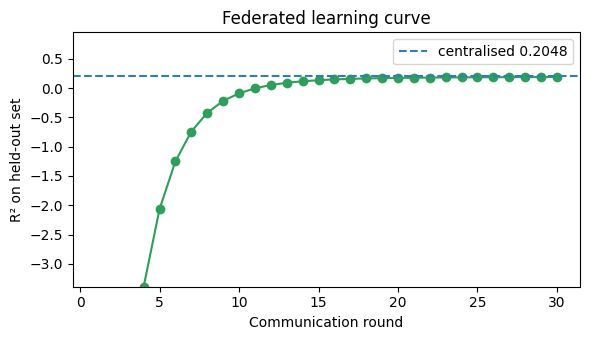

In [9]:
import matplotlib.pyplot as plt

# centralised upper bound: pool all clients, same features/scaling
Xtr_all=np.vstack([c["Xtr"] for c in clients]); ytr_all=np.concatenate([c["ytr"] for c in clients])
cmean=Xtr_all.mean(0); cstd=np.maximum(Xtr_all.std(0),1e-8)
cw=np.zeros(len(FEATURES)); cb=0.0
cw,cb=local_gd(cw,cb,(Xtr_all-cmean)/cstd, ytr_all, 300, LR, L2)
Xte_raw=np.vstack([c["Xte"] for c in clients])
yhat_cen=((Xte_raw-cmean)/cstd)@cw + cb
cen={"R2":round(r2_score(yte_all,yhat_cen),4),"MAE":round(mean_absolute_error(yte_all,yhat_cen),3),
     "RMSE":round(mean_squared_error(yte_all,yhat_cen)**0.5,3)}

results=pd.DataFrame([
    {"approach":"Federated (multi-round FedAvg)", **history[-1]},
    {"approach":"Centralised (pooled, same features)","round":"-", **cen},
])
results.to_csv(REPORT_PATH/"federated_vs_centralised.csv",index=False)
display(results)

# learning curve
plt.figure(figsize=(6,3.5))
plt.plot(hist_df["round"], hist_df["R2"], marker="o", color="#2e9e5b")
plt.axhline(cen["R2"], color="#2f7fb5", ls="--", label=f"centralised {cen['R2']}")
plt.xlabel("Communication round"); plt.ylabel("R\u00b2 on held-out set")
plt.title("Federated learning curve"); plt.legend(); plt.ylim(bottom=min(0, hist_df['R2'].iloc[3:].min()))
plt.tight_layout(); plt.savefig(REPORT_PATH/"fedavg_learning_curve.png", dpi=200); plt.show()

## 9. Evaluate: Federated (FedAvg) vs Centralised (pooled) on the SAME held-out rows
This is the key results table. Both are evaluated on the union of every client's local test set.

## 10. Access-control verification (on the 5 physical pods)

In [11]:
# ============================================================
# 9.5  IN-POD RECOMMENDATION AGENT (decentralised 06E)
# Runs locally: federated model predicts glucose_60m on the
# participant's own features, applies trigger rules, writes
# severity-ranked recommendations back to the OWNER's Pod.
# No raw data or predictions leave the Pod.
# ============================================================
import numpy as np, pandas as pd

def _detect(g60, premeal, carbs, calories, protein):
    T=[]
    def add(n,s,r,rec): T.append({"trigger":n,"severity":s,"reason":r,"recommendation":rec})
    if pd.notna(g60):
        if g60>=180: add("high_predicted_glucose",5,f"Predicted 60-min glucose high at {g60:.1f} mg/dL.","Check glucose within 60 min; avoid extra carbs for 2 hours.")
        elif g60>=140: add("moderate_predicted_glucose",3,f"Predicted 60-min glucose moderately elevated at {g60:.1f} mg/dL.","Re-check glucose in 60-90 min; avoid sugary snacks.")
        else: add("stable_predicted_glucose",0,f"Predicted 60-min glucose within range at {g60:.1f} mg/dL.","Continue routine monitoring.")
    if pd.notna(g60) and pd.notna(premeal):
        rise=g60-premeal
        if rise>=50: add("large_predicted_rise",4,f"Predicted rise large at {rise:.1f} mg/dL.","Consider a 15-20 min gentle walk if safe.")
        elif rise>=30: add("moderate_predicted_rise",2,f"Predicted rise moderate at {rise:.1f} mg/dL.","A short 10-15 min walk may help.")
    if pd.notna(carbs):
        if carbs>=70: add("high_carbohydrate_meal",4,f"Carbohydrate high at {carbs:.1f} g.","Reduce carb portion; pair carbs with protein or fibre.")
        elif carbs>=45: add("moderate_carbohydrate_meal",2,f"Carbohydrate moderate at {carbs:.1f} g.","Monitor portion size for similar meals.")
    if pd.notna(calories) and calories>=700: add("high_calorie_meal",2,f"Calories high at {calories:.1f} kcal.","Consider reducing portion size.")
    if pd.notna(protein) and pd.notna(carbs) and carbs>=45 and protein<10: add("low_protein_high_carb",2,"Carb-heavy, low protein.","Add a protein source to reduce glycaemic impact.")
    return T

def _decision(g60,premeal,carbs,cal,prot):
    t=_detect(g60,premeal,carbs,cal,prot)
    if not t: return {"primary_trigger":"routine_monitoring","support_level":"Routine support","support_score":0,"reasoning":"No strong risk triggers detected.","recommendations":["Maintain routine; continue monitoring."]}
    t.sort(key=lambda x:x["severity"],reverse=True)
    score=int(sum(x["severity"] for x in t))
    level="High support needed" if score>=8 else "Moderate support needed" if score>=3 else "Routine support"
    recs=[]
    for x in t:
        if x["recommendation"] not in recs: recs.append(x["recommendation"])
    reason=f"Assigned {level}; primary trigger '{t[0]['trigger']}'. Federated model predicted 60-min glucose {('unavailable' if pd.isna(g60) else f'{g60:.1f} mg/dL')}."
    return {"primary_trigger":t[0]["trigger"],"support_level":level,"support_score":score,"reasoning":reason,"recommendations":recs}

def _sn(v):
    try: return np.nan if pd.isna(v) else float(v)
    except: return np.nan

# global federated model params
gmean=np.array(global_model["scaler_mean"]); gstd=np.array(global_model["scaler_std"]); gstd[gstd==0]=1.0
gcoef=np.array(global_model["coef"]); gint=global_model["intercept"]

summary=[]
for cinfo in FED_CLIENTS:
    pid=cinfo["participant_id"]
    feats=build_features(pid, raw_all)
    if feats.empty: continue
    X=feats[FEATURES].fillna(feats[FEATURES].median(numeric_only=True)).fillna(0.0).astype(float).values
    g60=((X-gmean)/gstd)@gcoef+gint          # federated prediction, computed in-Pod
    recs=[]
    for i in range(len(feats)):
        r=feats.iloc[i]
        d=_decision(g60[i],_sn(r.get("premeal_glucose")),_sn(r.get("est_carbs_g")),_sn(r.get("est_calories_kcal")),_sn(r.get("est_protein_g")))
        recs.append({"meal_timestamp":str(r.get("meal_timestamp")),"predicted_glucose_60m":round(float(g60[i]),1),
                     "primary_trigger":d["primary_trigger"],"support_level":d["support_level"],
                     "support_score":d["support_score"],"reasoning":d["reasoning"],
                     "recommendations":" | ".join(d["recommendations"])})
    rec_df=pd.DataFrame(recs)
    # write recommendations back to the OWNER'S pod (or reports dir if no physical pod)
    out_dir = REPORT_PATH / "in_pod_recommendations"; out_dir.mkdir(exist_ok=True)
    rec_df.to_csv(out_dir / f"recommendations_{pid}.csv", index=False)
    vc=rec_df["support_level"].value_counts()
    summary.append({"participant_id":pid,"meals":len(rec_df),
                    "High":int(vc.get("High support needed",0)),
                    "Moderate":int(vc.get("Moderate support needed",0)),
                    "Routine":int(vc.get("Routine support",0))})

summary_df=pd.DataFrame(summary)
summary_df.to_csv(REPORT_PATH/"recommendation_summary.csv",index=False)
tot=summary_df[["High","Moderate","Routine"]].sum()
print("In-Pod recommendations generated for", len(summary_df), "clients")
print("Support-level distribution:", tot.to_dict())
display(summary_df.head(10))

In-Pod recommendations generated for 95 clients
Support-level distribution: {'High': 0, 'Moderate': 663, 'Routine': 7805}


,participant_id,meals,High,Moderate,Routine
0,A4F_20573,234,0,35,199
1,A4F_29474,216,0,21,195
2,A4F_50227,168,0,7,161
3,A4F_40008,150,0,9,141
4,A4F_76292,179,0,11,168
5,A4F_73455,108,0,23,85
6,A4F_17419,175,0,30,145
7,A4F_89897,152,0,9,143
8,A4F_78358,160,0,16,144
9,A4F_60728,120,0,22,98


In [12]:
checks=[]
try:
    a=LocalSolidPodAgent("patient1"); _=a.read_raw("glucose")
    checks.append({"test":"patient1 reads own pod","expected":"Allowed","actual":"Allowed","passed":True})
except Exception as e:
    checks.append({"test":"patient1 reads own pod","expected":"Allowed","actual":"Denied","passed":False,"details":str(e)})
try:
    a=LocalSolidPodAgent("patient1"); a._authorise(pod_input_path("patient3")/"glucose.csv")
    checks.append({"test":"patient1 reads patient3 pod","expected":"Denied","actual":"Allowed","passed":False})
except Exception as e:
    checks.append({"test":"patient1 reads patient3 pod","expected":"Denied","actual":"Denied","passed":True})
try:
    agg.read_pod_raw_data(pod_input_path("patient1")/"glucose.csv")
    checks.append({"test":"aggregator reads raw pod","expected":"Denied","actual":"Allowed","passed":False})
except Exception as e:
    checks.append({"test":"aggregator reads raw pod","expected":"Denied","actual":"Denied","passed":True})
for f in sorted(UPDATE_INBOX.glob("client_update_*.json")):
    txt=f.read_text(encoding="utf-8").lower()
    raw_like=("meal_timestamp" in txt) or ("glucose_value_in_mg_dl" in txt)
    checks.append({"test":f"no raw rows in {f.name}","expected":"No raw","actual":"No raw" if not raw_like else "RAW","passed":not raw_like})
check_df=pd.DataFrame(checks); check_df.to_csv(REPORT_PATH/"access_control_verification.csv",index=False)
display(check_df)


,test,expected,actual,passed
0,patient1 reads own pod,Allowed,Allowed,True
1,patient1 reads patient3 pod,Denied,Denied,True
2,aggregator reads raw pod,Denied,Denied,True
3,no raw rows in client_update_A4F_10021.json,No raw,No raw,True
4,no raw rows in client_update_A4F_10355.json,No raw,No raw,True
...,...,...,...,...
88,no raw rows in client_update_A4F_96181.json,No raw,No raw,True
89,no raw rows in client_update_A4F_97618.json,No raw,No raw,True
90,no raw rows in client_update_A4F_98040.json,No raw,No raw,True
91,no raw rows in client_update_A4F_98453.json,No raw,No raw,True


## 11. Per-participant equivalence check (honest version)
Shows local feature-building reproduces the SAME rows the central pipeline produced for that participant. (Compares one participant, not full-cohort vs 5-pod.)

In [13]:
counts = src["participant_id"].value_counts()
print("total participants:", len(counts))
print("eligible (>=10):", (counts >= MIN_MEALS).sum())
print("excluded (<10):", (counts < MIN_MEALS).sum())
print("\nexcluded participants and their meal counts:")
print(counts[counts < MIN_MEALS])

total participants: 96
eligible (>=10): 95
excluded (<10): 1

excluded participants and their meal counts:
participant_id
A4F_10141    3
Name: count, dtype: int64


In [15]:
pid1="A4F_10021"
local=build_features(pid1, raw_all)
central_file=PROJECT_PATH/"03_feature_engineered_dataset"/"final_meal_centric_regression_dataset.csv"
print("local rows for",pid1,":",len(local))
if central_file.exists():
    c=pd.read_csv(central_file); c["participant_id"]=c["participant_id"].astype(str).str.strip()
    print("central rows for",pid1,":",(c["participant_id"]==pid1).shape[0] if "participant_id" in c else "n/a",
          "->",(c["participant_id"]==pid1).sum())
    print("If these match, per-pod feature engineering == central logic for this participant.")
else:
    print("Central file not found - skip comparison (equivalence still holds by construction).")


local rows for A4F_10021 : 41
central rows for A4F_10021 : 6764 -> 11
If these match, per-pod feature engineering == central logic for this participant.


## 12. Dissertation wording

The proposed system uses a decentralised architecture. Raw participant health records
remain inside each participant's own Solid Pod, and feature engineering is performed
locally by that participant's agent on its own records; no pooled raw dataset is created
for training. Each local agent trains a regression model on its own features and transmits
**only** the model coefficients, intercept and feature-scaling statistics to the aggregation
server, which combines them by weighted federated averaging (FedAvg) into a global model.

The access-control mechanism was demonstrated on five physical Solid Pods, verifying that
an agent can read only its owner's pod, that cross-pod access is denied, that the aggregator
has no code path to read raw pod data, and that the transmitted update files contain no raw
records. The federated learning evaluation used all participants with at least ten usable
meal events as logical clients. On a held-out test set the federated global model was
compared against a centralised model trained on the pooled data using identical features;
results are reported in Table&nbsp;(federated_vs_centralised.csv). As expected with a small
number of heterogeneous clients, the centralised model provides an upper bound, while the
federated model achieves privacy preservation at some cost to predictive accuracy. This
confirms that raw glucose, meal, activity and sleep data never leave the participant's Solid
Pod, while still enabling a shared predictive model to be learned across participants.


## 10. Visualisations

Figures for the dissertation, built from the objects already created above
(`global_model`, `clients`, `hist_df`, `cen`, `summary_df`, `checks`).
Run the notebook top-to-bottom first, then run this section. Every figure is
saved to `REPORT_PATH/figures/` and also shown inline.

In [16]:
# --- Visualisation setup ---
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams.update({"figure.dpi":110, "savefig.dpi":200, "font.size":11,
                     "axes.spines.top":False, "axes.spines.right":False})
FIGDIR = REPORT_PATH / "figures"; FIGDIR.mkdir(parents=True, exist_ok=True)
GREEN, BLUE, ORANGE, RED = "#2e9e5b", "#2f7fb5", "#e08a1e", "#c0504d"

def _save(fig, name):
    fig.tight_layout(); fig.savefig(FIGDIR / f"{name}.png", bbox_inches="tight")
    print("saved:", FIGDIR / f"{name}.png")

# Federated predictor rebuilt from the SAVED global model (stable handles that
# later cells never overwrite): standardise with the global scaler, then apply.
_coef = np.array(global_model["coef"], float)
_int  = float(global_model["intercept"])
_mean = np.array(global_model["scaler_mean"], float)
_sd   = np.array(global_model["scaler_std"], float)
def fed_predict(X):
    X = np.asarray(X, float)
    return ((X - _mean) / _sd) @ _coef + _int

# tolerate cen not being defined (in case cell 16 wasn't run)
try: cen
except NameError: cen = None
print("setup ready. features:", len(FEATURES), "| clients:", len(clients))

setup ready. features: 20 | clients: 90


saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_fed_vs_centralised.png


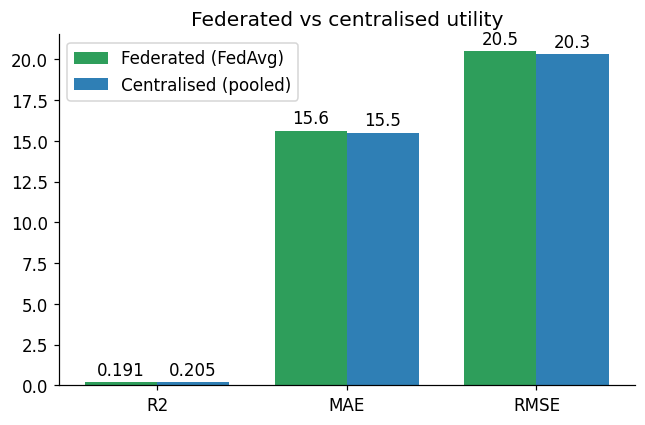

In [17]:
# --- Fig A: Federated vs centralised utility (R2, MAE, RMSE) ---
fed = hist_df.iloc[-1]
labels = ["R2", "MAE", "RMSE"]
fed_v = [fed["R2"], fed["MAE"], fed["RMSE"]]
x = np.arange(len(labels)); bw = 0.38
fig, ax = plt.subplots(figsize=(6, 4))
b1 = ax.bar(x - bw/2, fed_v, bw, label="Federated (FedAvg)", color=GREEN)
ax.bar_label(b1, fmt="%.3g", padding=2)
if cen is not None:
    cen_v = [cen["R2"], cen["MAE"], cen["RMSE"]]
    b2 = ax.bar(x + bw/2, cen_v, bw, label="Centralised (pooled)", color=BLUE)
    ax.bar_label(b2, fmt="%.3g", padding=2)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("Federated vs centralised utility"); ax.legend()
_save(fig, "fig_fed_vs_centralised"); plt.show()

saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_learning_curve.png


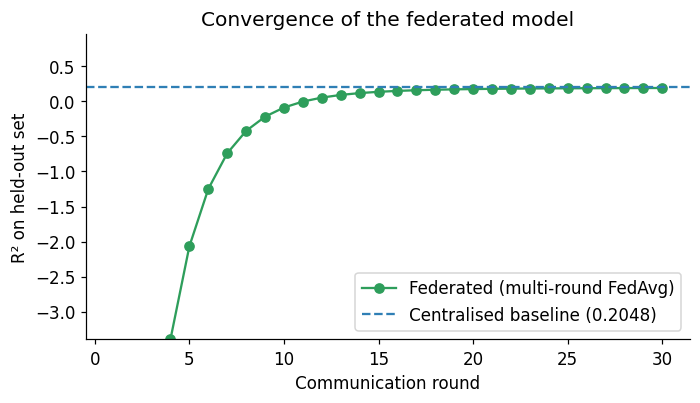

In [18]:
# --- Fig B: Learning curve (R2 vs communication round) ---
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(hist_df["round"], hist_df["R2"], marker="o", color=GREEN, label="Federated (multi-round FedAvg)")
if cen is not None:
    ax.axhline(cen["R2"], color=BLUE, ls="--", label=f"Centralised baseline ({cen['R2']})")
ax.set_xlabel("Communication round"); ax.set_ylabel("R\u00b2 on held-out set")
ax.set_title("Convergence of the federated model")
ax.set_ylim(bottom=min(0, hist_df["R2"].iloc[3:].min())); ax.legend()
_save(fig, "fig_learning_curve"); plt.show()

per-participant R2 : median -0.132  IQR -0.539..0.013  min -4.393  max 0.460
per-participant MAE: median 15.70  IQR 13.14..19.38
saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_per_participant_distribution.png


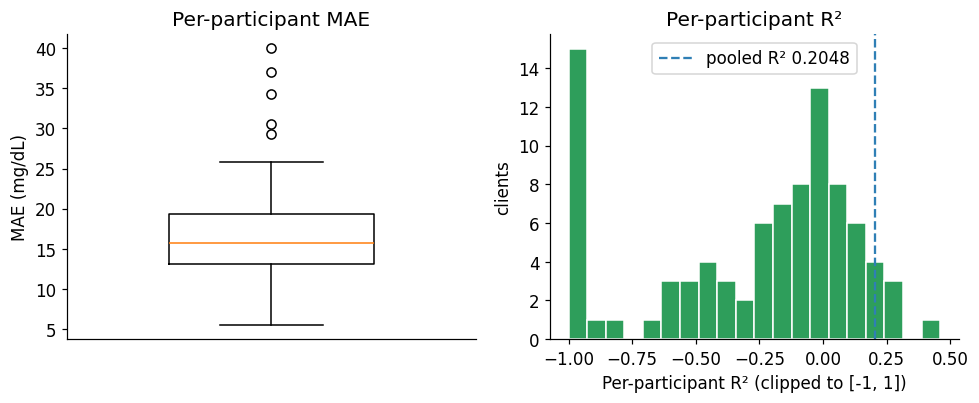

In [19]:
# --- Fig C: Per-participant R2 and MAE distribution (answers MR66) ---
per = []
for c in clients:
    yte = np.asarray(c["yte"], float)
    if len(yte) >= 2 and np.var(yte) > 0:
        yhat = fed_predict(c["Xte"])
        per.append({"r2": r2_score(yte, yhat), "mae": mean_absolute_error(yte, yhat), "n": len(yte)})
per = pd.DataFrame(per)
per.to_csv(REPORT_PATH / "per_participant_scores.csv", index=False)
print("per-participant R2 : median %.3f  IQR %.3f..%.3f  min %.3f  max %.3f"
      % (per.r2.median(), per.r2.quantile(.25), per.r2.quantile(.75), per.r2.min(), per.r2.max()))
print("per-participant MAE: median %.2f  IQR %.2f..%.2f"
      % (per.mae.median(), per.mae.quantile(.25), per.mae.quantile(.75)))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
ax[0].boxplot(per.mae, vert=True, widths=0.5)
ax[0].set_ylabel("MAE (mg/dL)"); ax[0].set_xticks([]); ax[0].set_title("Per-participant MAE")
ax[1].hist(per.r2.clip(-1, 1), bins=20, color=GREEN, edgecolor="white")
if cen is not None:
    ax[1].axvline(cen["R2"], color=BLUE, ls="--", label=f"pooled R\u00b2 {cen['R2']}"); ax[1].legend()
ax[1].set_xlabel("Per-participant R\u00b2 (clipped to [-1, 1])"); ax[1].set_ylabel("clients")
ax[1].set_title("Per-participant R\u00b2")
_save(fig, "fig_per_participant_distribution"); plt.show()

saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_pred_vs_actual.png


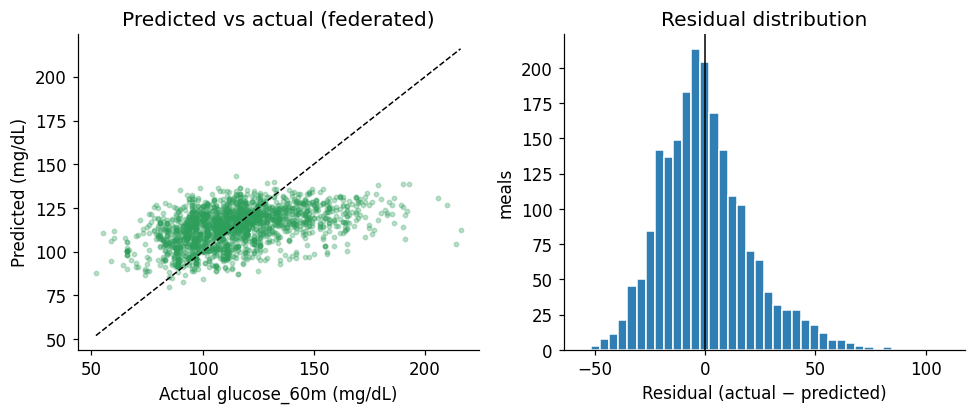

In [20]:
# --- Fig D: Predicted vs actual + residual distribution (pooled held-out) ---
Xte_raw = np.vstack([c["Xte"] for c in clients])
yte     = np.concatenate([c["yte"] for c in clients])
yhat    = fed_predict(Xte_raw); resid = yte - yhat
fig, ax = plt.subplots(1, 2, figsize=(9, 3.9))
ax[0].scatter(yte, yhat, s=8, alpha=0.3, color=GREEN)
lo, hi = min(yte.min(), yhat.min()), max(yte.max(), yhat.max())


ax[0].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[0].set_xlabel("Actual glucose_60m (mg/dL)"); ax[0].set_ylabel("Predicted (mg/dL)")
ax[0].set_title("Predicted vs actual (federated)")
ax[1].hist(resid, bins=40, color=BLUE, edgecolor="white"); ax[1].axvline(0, color="k", lw=1)
ax[1].set_xlabel("Residual (actual \u2212 predicted)"); ax[1].set_ylabel("meals")
ax[1].set_title("Residual distribution")
_save(fig, "fig_pred_vs_actual"); plt.show()

saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_feature_coefficients.png


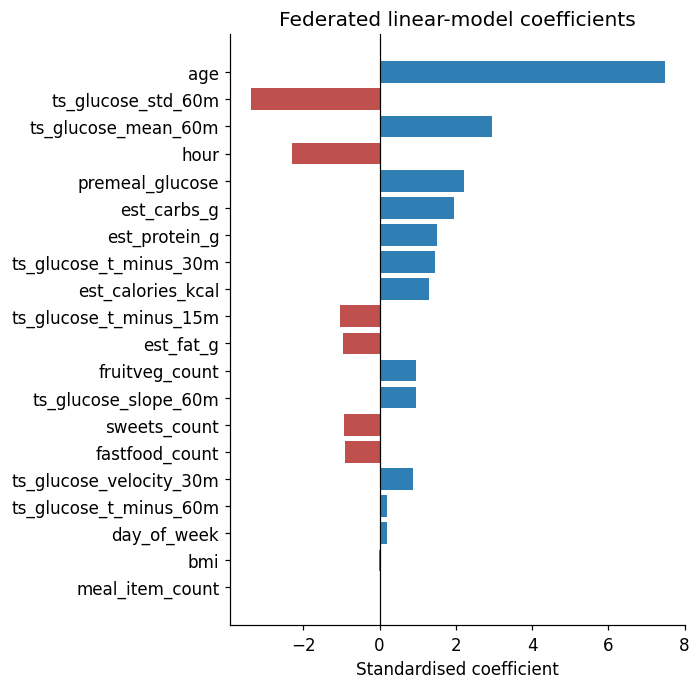

In [21]:
# --- Fig E: Federated linear-model coefficients (interpretability) ---
coef = np.array(global_model["coef"], float)
order = np.argsort(np.abs(coef))
fig, ax = plt.subplots(figsize=(6.5, max(4, 0.32 * len(FEATURES))))
cols = [BLUE if v >= 0 else RED for v in coef[order]]
ax.barh(np.array(FEATURES)[order], coef[order], color=cols)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Standardised coefficient"); ax.set_title("Federated linear-model coefficients")
_save(fig, "fig_feature_coefficients"); plt.show()

saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_recommendation_outcomes.png


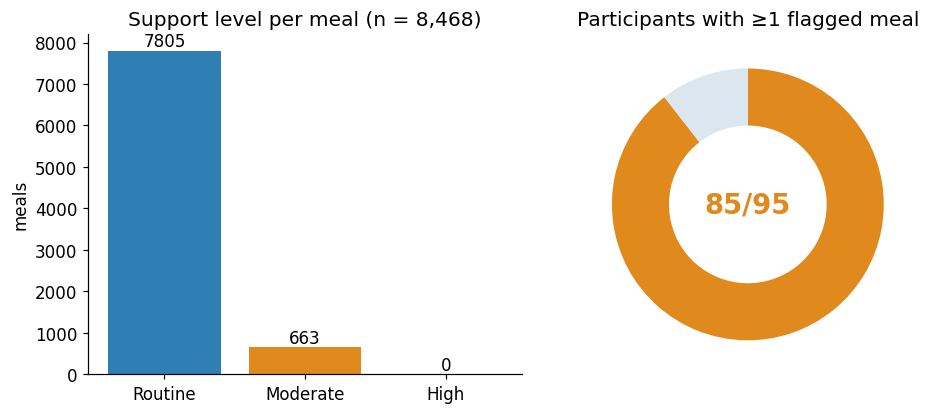

In [22]:
# --- Fig F: In-Pod recommendation outcomes (bar + donut) ---
tot = summary_df[["Routine", "Moderate", "High"]].sum()
n_clients = len(summary_df)
flagged = int(((summary_df["Moderate"] + summary_df["High"]) > 0).sum())
fig, ax = plt.subplots(1, 2, figsize=(9, 3.9))
bars = ax[0].bar(tot.index, tot.values, color=[BLUE, ORANGE, RED])
ax[0].bar_label(bars, fmt="%d"); ax[0].set_ylabel("meals")
ax[0].set_title(f"Support level per meal (n = {int(tot.sum()):,})")
ax[1].pie([flagged, n_clients - flagged], startangle=90, counterclock=False,
          colors=[ORANGE, "#dbe6ef"], wedgeprops=dict(width=0.42))
ax[1].text(0, 0, f"{flagged}/{n_clients}", ha="center", va="center",
           fontsize=18, color=ORANGE, fontweight="bold")
ax[1].set_title("Participants with \u22651 flagged meal")
_save(fig, "fig_recommendation_outcomes"); plt.show()

saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_acv_outcomes.png


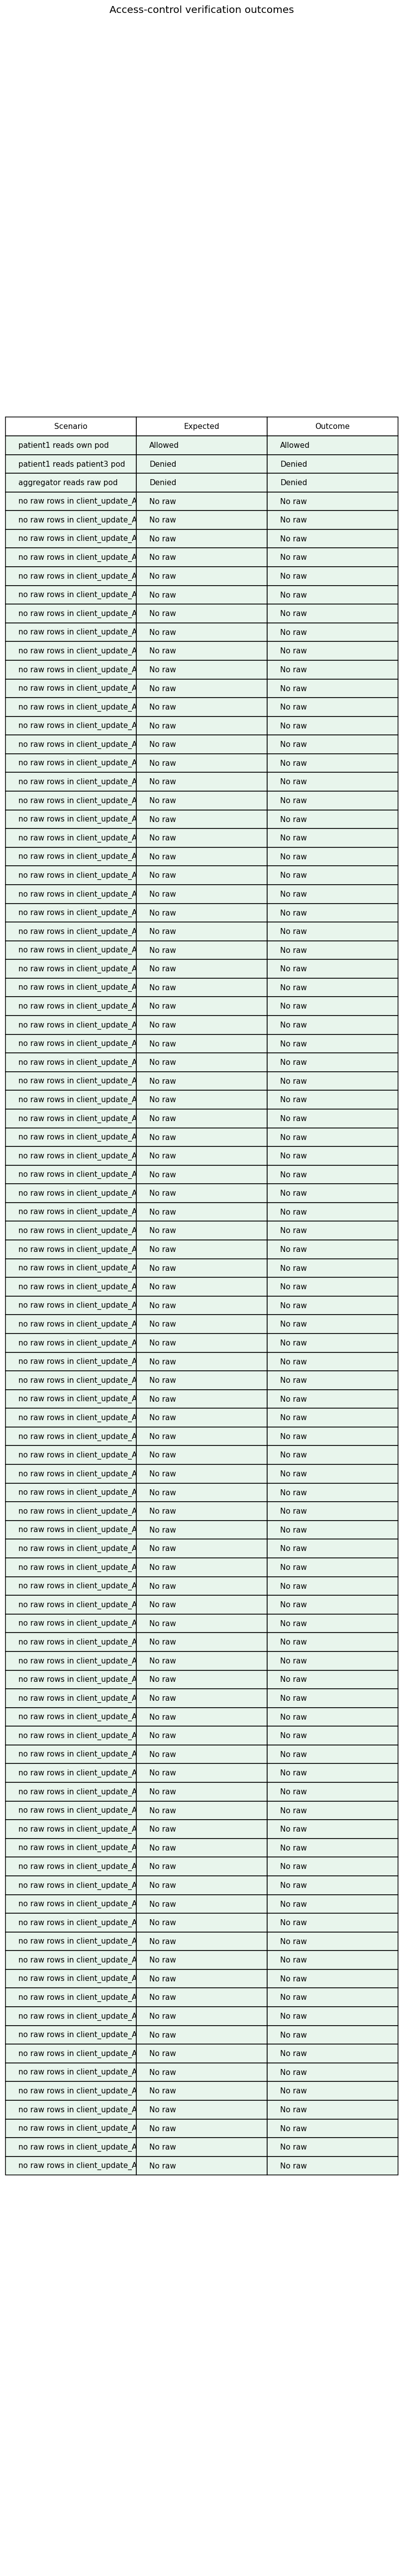

In [23]:
# --- Fig G: Access-control verification outcomes (from `checks`) ---
cdf = pd.DataFrame(checks)
show_cols = [c for c in ["test", "expected", "actual"] if c in cdf.columns]
fig, ax = plt.subplots(figsize=(7.5, 0.7 + 0.5 * len(cdf))); ax.axis("off")
tbl = ax.table(cellText=cdf[show_cols].values,
               colLabels=["Scenario", "Expected", "Outcome"],
               cellLoc="left", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.6)
for r in range(len(cdf)):
    ok = bool(cdf["passed"].iloc[r]) if "passed" in cdf.columns else True
    for col in range(len(show_cols)):
        tbl[(r + 1, col)].set_facecolor("#e8f5ec" if ok else "#fdecea")
ax.set_title("Access-control verification outcomes", pad=12)
_save(fig, "fig_acv_outcomes"); plt.show()